# Notebook 02 — Image Quality EDA (Computer Vision)

**Project:** DReel AI v2  
**Goal:** Analyze blur, brightness, contrast, and quality scores from uploaded images.

Data source: `data/image_features.csv`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
IMAGE_CSV = PROJECT_ROOT / "data" / "image_features.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
image_df = pd.read_csv(IMAGE_CSV)
image_df["timestamp"] = pd.to_datetime(image_df["timestamp"], utc=True)
image_df = image_df.drop_duplicates(subset=["reel_id", "filename"], keep="last")

image_df.head()

,timestamp,reel_id,filename,sort_rank,blur_variance,brightness,contrast,quality_score,quality_label
0,2026-07-09 10:00:07.043002+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,The_compassionate_Krishna.jpg,1,1265.70,120.93,72.56,0.9630,good
1,2026-07-09 10:00:07.043002+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,bali3.jpg,2,997.27,131.00,69.41,0.9610,good
2,2026-07-09 10:00:07.043002+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,bhem-maya-kris.jpg,3,2301.32,100.57,83.51,0.9464,good
3,2026-07-09 10:00:07.043002+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,bali_1_1.jpg,4,1661.97,140.34,63.29,0.9237,good
4,2026-07-09 10:00:07.043002+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,Bheem-and-Chutkis_Arabian_Style.jpg,5,768.44,141.40,53.68,0.8916,good


## 1. Dataset Overview

In [3]:
print(f"Total images analyzed: {len(image_df)}")
print(f"Unique reels: {image_df['reel_id'].nunique()}")
print("\nQuality label distribution:")
print(image_df["quality_label"].value_counts())
image_df.describe().round(3)

Total images analyzed: 7
Unique reels: 1

Quality label distribution:
quality_label
good    7
Name: count, dtype: int64


,sort_rank,blur_variance,brightness,contrast,quality_score
count,7.00,7.000,7.000,7.000,7.000
mean,4.00,1169.824,108.597,61.901,0.874
std,2.16,639.789,35.040,14.554,0.113
min,1.00,400.520,48.810,42.130,0.683
25%,2.50,780.995,88.850,51.205,0.820
50%,4.00,997.270,120.930,63.290,0.924
75%,5.50,1463.835,135.670,70.985,0.954
max,7.00,2301.320,141.400,83.510,0.963


## 2. Quality Score Distribution

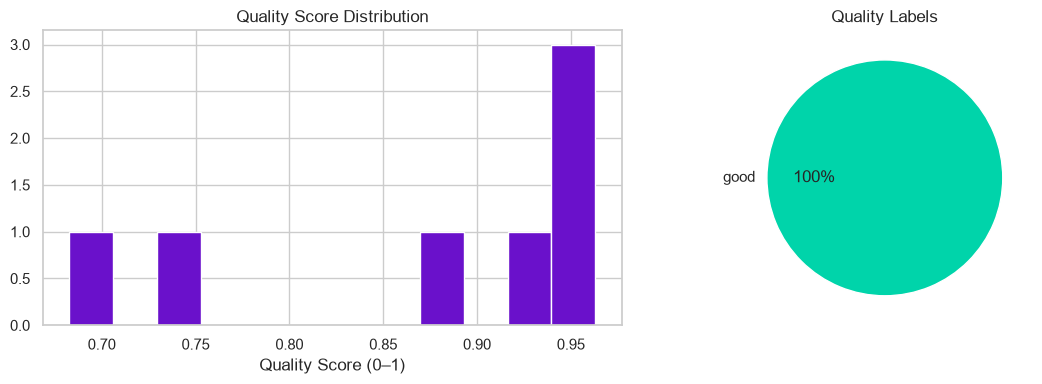

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(image_df["quality_score"], bins=12, color="#6a11cb", edgecolor="white")
axes[0].set_title("Quality Score Distribution")
axes[0].set_xlabel("Quality Score (0–1)")

label_counts = image_df["quality_label"].value_counts()
colors = {"good": "#00d4aa", "fair": "#ffc107", "poor": "#ff4d4d"}
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.0f%%",
    colors=[colors.get(label, "#2575fc") for label in label_counts.index],
)
axes[1].set_title("Quality Labels")

plt.tight_layout()
plt.show()

## 3. Blur, Brightness & Contrast

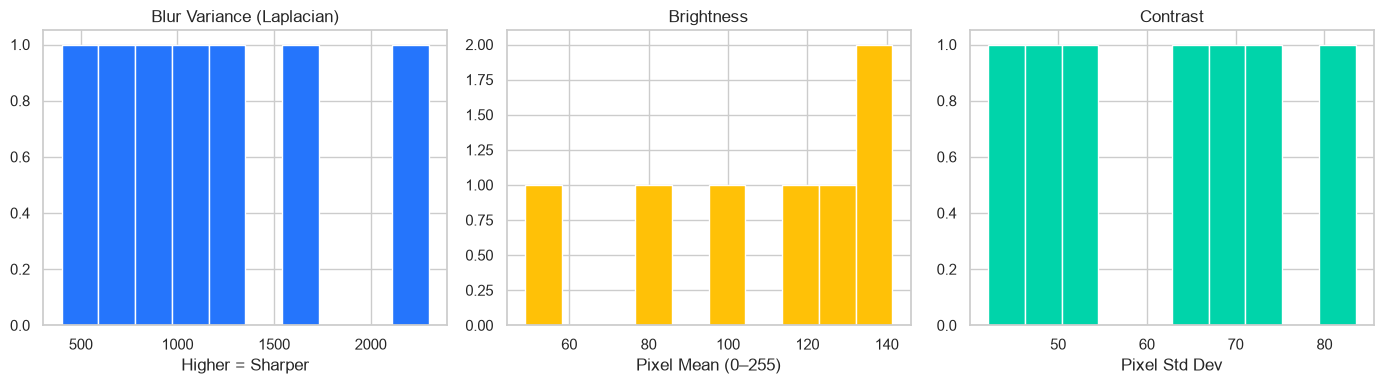

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(image_df["blur_variance"], bins=10, color="#2575fc", edgecolor="white")
axes[0].set_title("Blur Variance (Laplacian)")
axes[0].set_xlabel("Higher = Sharper")

axes[1].hist(image_df["brightness"], bins=10, color="#ffc107", edgecolor="white")
axes[1].set_title("Brightness")
axes[1].set_xlabel("Pixel Mean (0–255)")

axes[2].hist(image_df["contrast"], bins=10, color="#00d4aa", edgecolor="white")
axes[2].set_title("Contrast")
axes[2].set_xlabel("Pixel Std Dev")

plt.tight_layout()
plt.show()

## 4. Sharpness vs Quality Relationship

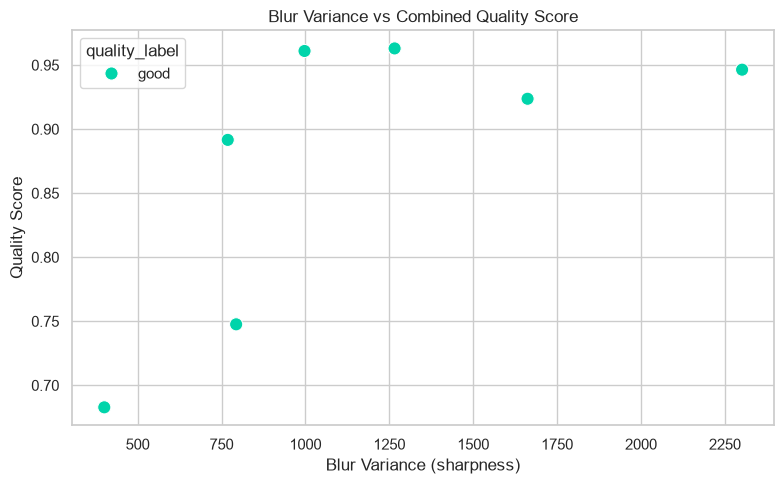

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=image_df,
    x="blur_variance",
    y="quality_score",
    hue="quality_label",
    palette={"good": "#00d4aa", "fair": "#ffc107", "poor": "#ff4d4d"},
    s=90,
    edgecolor="white",
)
plt.title("Blur Variance vs Combined Quality Score")
plt.xlabel("Blur Variance (sharpness)")
plt.ylabel("Quality Score")
plt.tight_layout()
plt.show()

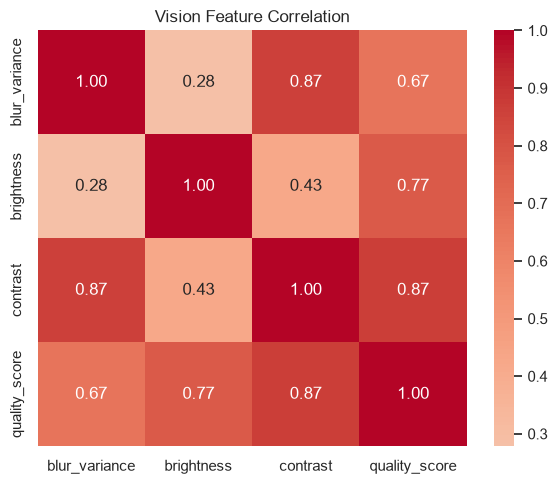

In [7]:
corr = image_df[["blur_variance", "brightness", "contrast", "quality_score"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Vision Feature Correlation")
plt.tight_layout()
plt.show()

## 5. Auto-Ranking Impact

Images are sorted by `quality_score` before reel generation — best quality images appear first.

In [8]:
ranked = image_df.sort_values(["reel_id", "sort_rank"])
ranked[["filename", "sort_rank", "quality_score", "quality_label"]].head(10)

,filename,sort_rank,quality_score,quality_label
0,The_compassionate_Krishna.jpg,1,0.9630,good
1,bali3.jpg,2,0.9610,good
2,bhem-maya-kris.jpg,3,0.9464,good
3,bali_1_1.jpg,4,0.9237,good
4,Bheem-and-Chutkis_Arabian_Style.jpg,5,0.8916,good
5,cbha2.jpg,6,0.7476,good
6,Bheem_the_fighter.jpg,7,0.6828,good


## 6. Key Findings

- **Blur variance** (Laplacian) is the strongest indicator of perceived image sharpness.
- **Brightness** near 128 and higher **contrast** improve the combined quality score.
- The vision pipeline auto-ranks images so the best frames lead each reel.
- Low-quality images can be flagged at upload time with user warnings.